In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime
from recommenders.lmf import LogisticMatrixFactorization

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

In [4]:
# df = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)
# df["type"] = "top_track"
# spoti.NUMERICAL_FEATURES = ["danceability", "instrumentalness", "duration_ms"]
# spoti.PRETTY_PRINT_FEATURES = ["username", "id", "danceability", "instrumentalness", "duration_ms"]
# df

In [5]:
# df = pd.read_csv(os.path.join(data_path.DATA_PATH, "ratings.csv"))
# df["type"] = "top_track"
# df.columns = ["username", "id", "affinity", "timestamp", "type"]
# df

## Setup the dataset

In [6]:
df_matrix_mf = df.copy()
df_matrix_mf.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")
df_matrix_mf

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_62145/1256999401.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12422,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,330733,False,{'isrc': 'GBN9X1400200'},{'spotify': 'https://open.spotify.com/track/16...,https://api.spotify.com/v1/tracks/16KX9LfZCjRP...,16KX9LfZCjRPdX84PX1XF9,...,NaN,0.30,dany,2014,"[rock, rock, rock, rock, rock, rock, rock]",2022-01-28 08:37:40+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12423,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,1026853,False,{'isrc': 'GBN9Y1800013'},{'spotify': 'https://open.spotify.com/track/71...,https://api.spotify.com/v1/tracks/715b4AT3ynJy...,715b4AT3ynJyYmtFucyzDu,...,NaN,0.30,dany,1977,"[rock, rock, rock, rock, rock, rock, rock]",2022-09-25 09:41:36+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.30,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7

In [7]:
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf, "id", 2)
df_matrix_mf_filtered

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
7,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,188106,False,{'isrc': 'USSM12107750'},{'spotify': 'https://open.spotify.com/track/6Y...,https://api.spotify.com/v1/tracks/6Y46tOTRhkBa...,6Y46tOTRhkBamosyuWa6YX,...,medium_term,0.86,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
14,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196519,False,{'isrc': 'QMJMT2204481'},{'spotify': 'https://open.spotify.com/track/35...,https://api.spotify.com/v1/tracks/35ovElsgyAtQ...,35ovElsgyAtQwYPYnZJECg,...,medium_term,0.72,jaslkh,2022,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
15,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,282052,False,{'isrc': 'FRUM71700532'},{'spotify': 'https://open.spotify.com/track/5x...,https://api.spotify.com/v1/tracks/5xYNLzZzgN3r...,5xYNLzZzgN3r6YPcQgNcJD,...,medium_term,0.70,jaslkh,2017,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
16,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,155893,False,{'isrc': 'FR9W12145737'},{'spotify': 'https://open.spotify.com/track/3n...,https://api.spotify.com/v1/tracks/3nR6ytbSKOF4...,3nR6ytbSKOF4NxsgqrYG9u,...,medium_term,0.68,jaslkh,2022,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
23,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,187320,False,{'isrc': 'GBENL1601640'},{'spotify': 'https://open.spotify.com/track/3N...,https://api.spotify.com/v1/tracks/3NfqN997u9A3...,3NfqN997u9A3YAAafgzhIa,...,medium_term,0.54,jaslkh,2016,"[rock, rock, emo, rock]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12386,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,365626,False,{'isrc': 'GBAYE7800619'},{'spotify': 'https://open.spotify.com/track/5g...,https://api.spotify.com/v1/tracks/5gOd6zDC8vhl...,5gOd6zDC8vhlYjqbQdJVWP,...,NaN,0.50,dany,1978,"[rock, rock, rock, rock, rock]",2019-12-09 06:53:08+00:00,NaN,NaN,NaN,NaN
12390,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,1413306,False,{'isrc': 'GBN9Y1100065'},{'spotify': 'https://open.spotify.com/track/1M...,https://api.spotify.com/v1/tracks/1Mzm1CNqVxtw...,1Mzm1CNqVxtwbCYhOo843s,...,NaN,0.30,dany,1971,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:49:49+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12393,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,284413,False,{'isrc': 'GBN9Y1100080'},{'spotify': 'https://open.spotify.com/track/25...,https://api.spotify.com/v1/tracks/25tZHMv3ctlz...,25tZHMv3ctlzqDaHAeuU9c,...,NaN,0.30,dany,1973,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:50:19+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12399,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,304200,False,{'isrc': 'GBN9Y1100088'},{'spotify': 'https://open.spotify.com/track/7a...,https://api.spotify.com/v1/tracks/7aE5WXu5sFeN...,7aE5WXu5sFeNRh3Z05wwu4,...,NaN,0.30,dany,1975,"[rock, rock, rock, rock,

In [8]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 8 users, 6320 items and 917 interactions, so the sparsity is 1.81%.


In [9]:
df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_62145/3495685520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_62145/3495685520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()


In [10]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
display(shuffled_users_df)

username
owen         274
michelle     116
jaslkh       112
paul         112
lsirwguhu    108
arthur        81
brenda        69
dany          45
Name: count, dtype: int64

,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu
paul,112,paul
brenda,69,brenda


In [11]:
train_df, val_df, test_df = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.2, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df)
print("Validation data:")
display(val_df)
print("Test data:")
display(test_df)

Original data:


,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu
paul,112,paul
brenda,69,brenda


Train data:


,count,old_index
username,,
michelle,116,michelle
arthur,81,arthur
owen,274,owen
dany,45,dany


Validation data:


,count,old_index
username,,
jaslkh,112,jaslkh
lsirwguhu,108,lsirwguhu


Test data:


,count,old_index
username,,
paul,112,paul
brenda,69,brenda


Train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
1505,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,239597,False,{'isrc': 'TCACP1635569'},{'spotify': 'https://open.spotify.com/track/4y...,https://api.spotify.com/v1/tracks/4yXKLDrHYrff...,4yXKLDrHYrffSVmQOFdbDA,...,medium_term,1.00,owen,2016,"[emo, emo, emo, indie, emo]",NaT,NaN,NaN,NaN,NaN
1507,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,276000,True,{'isrc': 'TCACP1635556'},{'spotify': 'https://open.spotify.com/track/19...,https://api.spotify.com/v1/tracks/19aUuDd6udp1...,19aUuDd6udp1ACNo9t3IuZ,...,medium_term,0.96,owen,2016,"[emo, emo, emo, indie, emo]",NaT,NaN,NaN,NaN,NaN
1514,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,250546,False,{'isrc': 'USRW29600011'},{'spotify': 'https://open.spotify.com/track/5U...,https://api.spotify.com/v1/tracks/5UWwZ5lm5PKu...,5UWwZ5lm5PKu6eKsHAGxOk,...,medium_term,0.82,owen,1997,"[metal, rock, rock, emo, grunge, rock]",NaT,NaN,NaN,NaN,NaN
1517,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, BE, BG, BH, BO, BR, CA, CH, C...",1,193911,False,{'isrc': 'QMCE71300252'},{'spotify': 'https://open.spotify.com/track/5b...,https://api.spotify.com/v1/tracks/5bwxMo2sye4b...,5bwxMo2sye4bffTgp7uNbo,...,medium_term,0.76,owen,2015,"[emo, lofi, emo, emo]",NaT,NaN,NaN,NaN,NaN
1519,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,265360,True,{'isrc': 'USRC12301954'},{'spotify': 'https://open.spotify.com/track/7d...,https://api.spotify.com/v1/tracks/7dJYggqjKo71...,7dJYggqjKo71KI9sLzqCs8,...,medium_term,0.72,owen,2023,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12386,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,365626,False,{'isrc': 'GBAYE7800619'},{'spotify': 'https://open.spotify.com/track/5g...,https://api.spotify.com/v1/tracks/5gOd6zDC8vhl...,5gOd6zDC8vhlYjqbQdJVWP,...,NaN,0.50,dany,1978,"[rock, rock, rock, rock, rock]",2019-12-09 06:53:08+00:00,NaN,NaN,NaN,NaN
12390,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,1413306,False,{'isrc': 'GBN9Y1100065'},{'spotify': 'https://open.spotify.com/track/1M...,https://api.spotify.com/v1/tracks/1Mzm1CNqVxtw...,1Mzm1CNqVxtwbCYhOo843s,...,NaN,0.30,dany,1971,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:49:49+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12393,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,284413,False,{'isrc': 'GBN9Y1100080'},{'spotify': 'https://open.spotify.com/track/25...,https://api.spotify.com/v1/tracks/25tZHMv3ctlz...,25tZHMv3ctlzqDaHAeuU9c,...,NaN,0.30,dany,1973,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:50:19+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12399,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,304200,False,{'isrc': 'GBN9Y1100088'},{'spotify': 'https://open.spotify.com/track/7a...,https://api.spotify.com/v1/tracks/7aE5WXu5sFeN...,7aE5WXu5sFeNRh3Z05wwu4,...

Validation train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
14,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196519,False,{'isrc': 'QMJMT2204481'},{'spotify': 'https://open.spotify.com/track/35...,https://api.spotify.com/v1/tracks/35ovElsgyAtQ...,35ovElsgyAtQwYPYnZJECg,...,medium_term,0.72,jaslkh,2022,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
43,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BG, BH, BO, BR, CA, CH, C...",1,251253,False,{'isrc': 'USUM71021480'},{'spotify': 'https://open.spotify.com/track/6m...,https://api.spotify.com/v1/tracks/6mHOcVtsHLMu...,6mHOcVtsHLMuesJkswc0GZ,...,medium_term,0.14,jaslkh,1979,"[rock, rock, rock, rock, rock, rock, rock, roc...",NaT,NaN,NaN,NaN,NaN
72,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,224000,True,{'isrc': 'QM5FT1600120'},{'spotify': 'https://open.spotify.com/track/5o...,https://api.spotify.com/v1/tracks/5oO3drDxtziY...,5oO3drDxtziYU2H1X23ZIp,...,short_term,0.56,jaslkh,2016,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
112,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,257800,False,{'isrc': 'USWB11301111'},{'spotify': 'https://open.spotify.com/track/0o...,https://api.spotify.com/v1/tracks/0ofHAoxe9vBk...,0ofHAoxe9vBkTCp2UQIavz,...,long_term,0.76,jaslkh,1977,"[rock, rock, rock, rock, rock]",NaT,NaN,NaN,NaN,NaN
115,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,299873,True,{'isrc': 'FR9W12006017'},{'spotify': 'https://open.spotify.com/track/2U...,https://api.spotify.com/v1/tracks/2Uv2DyJ1EiJ8...,2Uv2DyJ1EiJ8FawI9mCDTp,...,long_term,0.70,jaslkh,2019,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12119,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,298333,False,{'isrc': 'GBA076800030'},{'spotify': 'https://open.spotify.com/track/3X...,https://api.spotify.com/v1/tracks/3Xls4cNOwy01...,3Xls4cNOwy01dtrNXb1inG,...,NaN,0.30,lsirwguhu,1968,"[rock, jazz/blues, english, rock, rock, rock, ...",2020-08-31 07:43:36+00:00,False,True,loris.palma,60LLfcAgSHTbpiQNnhTuWT
12126,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,320266,False,{'isrc': 'USSM19802337'},{'spotify': 'https://open.spotify.com/track/0u...,https://api.spotify.com/v1/tracks/0uEp9E98JB5a...,0uEp9E98JB5awlA084uaIg,...,NaN,0.30,lsirwguhu,1998,"[rnb, rap, rap, rnb, rap, rnb, rnb]",2020-09-06 06:59:03+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT
12135,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,198800,False,{'isrc': 'USJI10301005'},{'spotify': 'https://open.spotify.com/track/6I...,https://api.spotify.com/v1/tracks/6I9VzXrHxO9r...,6I9VzXrHxO9rA9A5euc8Ak,...,NaN,0.30,lsirwguhu,2003,"[pop, pop]",2020-09-06 11:34:06+00:00,False,True,thibault.aboud,60LLfcAgSHTbpiQNnhTuWT
12136,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,219466,False,{'isrc': 'GBAYK8800055'},{'spotify': 'https://open.spotify.com/track/66...,https://api.spotify.com/v1/tracks/66S14BkJDxgk...,66S14BkJDxgkYxLl5DCqOz,...,NaN,0.3

Validation test data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
7,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,188106,False,{'isrc': 'USSM12107750'},{'spotify': 'https://open.spotify.com/track/6Y...,https://api.spotify.com/v1/tracks/6Y46tOTRhkBa...,6Y46tOTRhkBamosyuWa6YX,...,medium_term,0.86,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
15,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,282052,False,{'isrc': 'FRUM71700532'},{'spotify': 'https://open.spotify.com/track/5x...,https://api.spotify.com/v1/tracks/5xYNLzZzgN3r...,5xYNLzZzgN3r6YPcQgNcJD,...,medium_term,0.70,jaslkh,2017,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
16,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,155893,False,{'isrc': 'FR9W12145737'},{'spotify': 'https://open.spotify.com/track/3n...,https://api.spotify.com/v1/tracks/3nR6ytbSKOF4...,3nR6ytbSKOF4NxsgqrYG9u,...,medium_term,0.68,jaslkh,2022,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
23,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,187320,False,{'isrc': 'GBENL1601640'},{'spotify': 'https://open.spotify.com/track/3N...,https://api.spotify.com/v1/tracks/3NfqN997u9A3...,3NfqN997u9A3YAAafgzhIa,...,medium_term,0.54,jaslkh,2016,"[rock, rock, emo, rock]",NaT,NaN,NaN,NaN,NaN
36,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,144826,False,{'isrc': 'FRZ196200210'},{'spotify': 'https://open.spotify.com/track/6r...,https://api.spotify.com/v1/tracks/6rqUOLt9dpfM...,6rqUOLt9dpfMANLMKTzoWj,...,medium_term,0.28,jaslkh,1962,"[french, ye ye]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12106,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,213066,True,{'isrc': 'USIR10500407'},{'spotify': 'https://open.spotify.com/track/2y...,https://api.spotify.com/v1/tracks/2ygMBIctKIAf...,2ygMBIctKIAfbEBcT9065L,...,NaN,0.30,lsirwguhu,2005,"[pop, pop, pop]",2020-08-31 07:33:29+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT
12112,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,171533,False,{'isrc': 'USMC10110874'},{'spotify': 'https://open.spotify.com/track/1f...,https://api.spotify.com/v1/tracks/1fJFuvU2ldme...,1fJFuvU2ldmeAm5nFIHcPP,...,NaN,0.30,lsirwguhu,2001,"[metal, rock, punk, punk, rock, punk]",2020-08-31 07:34:16+00:00,False,True,loris.palma,60LLfcAgSHTbpiQNnhTuWT
12128,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,224000,True,{'isrc': 'QM5FT1600120'},{'spotify': 'https://open.spotify.com/track/5o...,https://api.spotify.com/v1/tracks/5oO3drDxtziY...,5oO3drDxtziYU2H1X23ZIp,...,NaN,0.30,lsirwguhu,2016,"[pop, pop, rap]",2020-09-10 00:24:54+00:00,False,True,unemortelle,60LLfcAgSHTbpiQNnhTuWT
12151,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,155906,False,{'isrc': 'CHT531000202'},{'spotify': 'https://open.spotify.com/track/5M...,https://api.spotify.com/v1/tracks/5M5qggHWyKCM...,5M5qggHWyKCMJ2TPjBG6uV,...,NaN,0.30,lsirwguhu,2011,[alpine yodeling],2020-09-06 11:40:14+00:00,False,Tru

Test train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
6969,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,231826,False,{'isrc': 'USCJY1431309'},{'spotify': 'https://open.spotify.com/track/1u...,https://api.spotify.com/v1/tracks/1u8c2t2Cy7UB...,1u8c2t2Cy7UBoG4ArRcF5g,...,medium_term,0.94,brenda,2014,[pop],NaT,NaN,NaN,NaN,NaN
6976,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,225280,False,{'isrc': 'USWB19901214'},{'spotify': 'https://open.spotify.com/track/2W...,https://api.spotify.com/v1/tracks/2WfaOiMkCvy7...,2WfaOiMkCvy7F5fcp2zZ8L,...,medium_term,0.80,brenda,1985,"[new romantic, emo, emo, emo, pop]",NaT,NaN,NaN,NaN,NaN
6977,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,284373,False,{'isrc': 'USUM70967700'},{'spotify': 'https://open.spotify.com/track/3F...,https://api.spotify.com/v1/tracks/3F9ByoUqu31x...,3F9ByoUqu31xU0I3G5xfVg,...,medium_term,0.78,brenda,2009,"[pop, pop, pop]",NaT,NaN,NaN,NaN,NaN
6997,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,367306,False,{'isrc': 'DEAE60900757'},{'spotify': 'https://open.spotify.com/track/1f...,https://api.spotify.com/v1/tracks/1fmoCZ6mtMiq...,1fmoCZ6mtMiqA5GHWPcZz9,...,medium_term,0.38,brenda,2009,"[electronic, indie]",NaT,NaN,NaN,NaN,NaN
7049,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, BE, BG, BH, BO, BR, CA, CH, C...",1,209438,False,{'isrc': 'QZES71982312'},{'spotify': 'https://open.spotify.com/track/2X...,https://api.spotify.com/v1/tracks/2XU0oxnq2qxC...,2XU0oxnq2qxCpomAAuJY8K,...,short_term,0.34,brenda,2019,[pop],NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11253,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,248853,False,{'isrc': 'FR7U61000024'},{'spotify': 'https://open.spotify.com/track/4g...,https://api.spotify.com/v1/tracks/4g0kyRLFKBYF...,4g0kyRLFKBYFxDF1vCxj8v,...,NaN,0.30,paul,2010,"[rap, pop, pop, rap]",2020-08-09 14:24:46+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11255,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,204453,False,{'isrc': 'FR7U61000025'},{'spotify': 'https://open.spotify.com/track/5N...,https://api.spotify.com/v1/tracks/5NsOnvpjvH9s...,5NsOnvpjvH9sCz8TyVOmOz,...,NaN,0.30,paul,2010,"[rap, pop, pop, rap]",2020-08-09 14:24:51+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11275,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,337560,False,{'isrc': 'USQX91300105'},{'spotify': 'https://open.spotify.com/track/2c...,https://api.spotify.com/v1/tracks/2cGxRwrMyEAp...,2cGxRwrMyEAp8dEbuZaVv6,...,NaN,0.30,paul,2013,"[electronic, electronic, rock]",2020-08-09 14:48:31+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11277,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,320357,False,{'isrc': 'GBDUW0000053'},{'spotify': 'https://open.spotify.com/track/0D...,https://api.spotify.com/v1/tracks/0DiWol3AO6Wp...,0DiWol3AO6WpXZgp0goxAV,...,NaN,0.30,paul,2001,"[electronic, electronic, rock]",2020-08-09 14:51

Test test data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
6967,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196800,False,{'isrc': 'BE8HB1990007'},{'spotify': 'https://open.spotify.com/track/7r...,https://api.spotify.com/v1/tracks/7rBP4bLjMLNk...,7rBP4bLjMLNkix1nGHjheP,...,medium_term,0.98,brenda,2019,"[pop, pop, french]",NaT,NaN,NaN,NaN,NaN
6971,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,238266,False,{'isrc': 'USSM18300548'},{'spotify': 'https://open.spotify.com/track/4y...,https://api.spotify.com/v1/tracks/4y1LsJpmMti1...,4y1LsJpmMti1PfRQV9AWWe,...,medium_term,0.90,brenda,1983,"[pop, emo, emo, rock]",NaT,NaN,NaN,NaN,NaN
6978,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,213066,True,{'isrc': 'USIR10500407'},{'spotify': 'https://open.spotify.com/track/2y...,https://api.spotify.com/v1/tracks/2ygMBIctKIAf...,2ygMBIctKIAfbEBcT9065L,...,medium_term,0.76,brenda,2005,"[pop, pop, pop]",NaT,NaN,NaN,NaN,NaN
6981,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,173381,False,{'isrc': 'USUM72119916'},{'spotify': 'https://open.spotify.com/track/1r...,https://api.spotify.com/v1/tracks/1r9xUipOqoNw...,1r9xUipOqoNwggBpENDsvJ,...,medium_term,0.70,brenda,2021,"[rock, pop, rock]",NaT,NaN,NaN,NaN,NaN
6984,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,299960,False,{'isrc': 'USSM11707035'},{'spotify': 'https://open.spotify.com/track/2Y...,https://api.spotify.com/v1/tracks/2Y0iGXY6m6im...,2Y0iGXY6m6immVb2ktbseM,...,medium_term,0.64,brenda,2018,"[rock, indie, indie, rock, rock]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11199,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,227266,False,{'isrc': 'GBARL1401201'},{'spotify': 'https://open.spotify.com/track/7M...,https://api.spotify.com/v1/tracks/7MmG8p0F9N3C...,7MmG8p0F9N3C4AXdK6o6Eb,...,NaN,0.30,paul,2014,"[pop, electronic, electronic, electronic, pop,...",2020-08-09 14:06:36+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11249,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,262146,False,{'isrc': 'USUM71100061'},{'spotify': 'https://open.spotify.com/track/7m...,https://api.spotify.com/v1/tracks/7mitXLIMCflk...,7mitXLIMCflkhZiD34uEQI,...,NaN,0.30,paul,2011,"[pop, pop, pop]",2020-08-09 14:24:16+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11273,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,275386,False,{'isrc': 'USQX91300101'},{'spotify': 'https://open.spotify.com/track/0d...,https://api.spotify.com/v1/tracks/0dEIca2nhcxD...,0dEIca2nhcxDUV8C5QkPYb,...,NaN,0.30,paul,2013,"[electronic, electronic, rock]",2020-08-09 14:48:19+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
11313,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,284373,False,{'isrc': 'USUM70967700'},{'spotify': 'https://open.spotify.com/track/3F...,https://api.spotify.com/v1/tracks/3F9ByoUqu31x...,3F9ByoUqu31xU0I3G5xfVg,...,NaN,0.30,paul,2

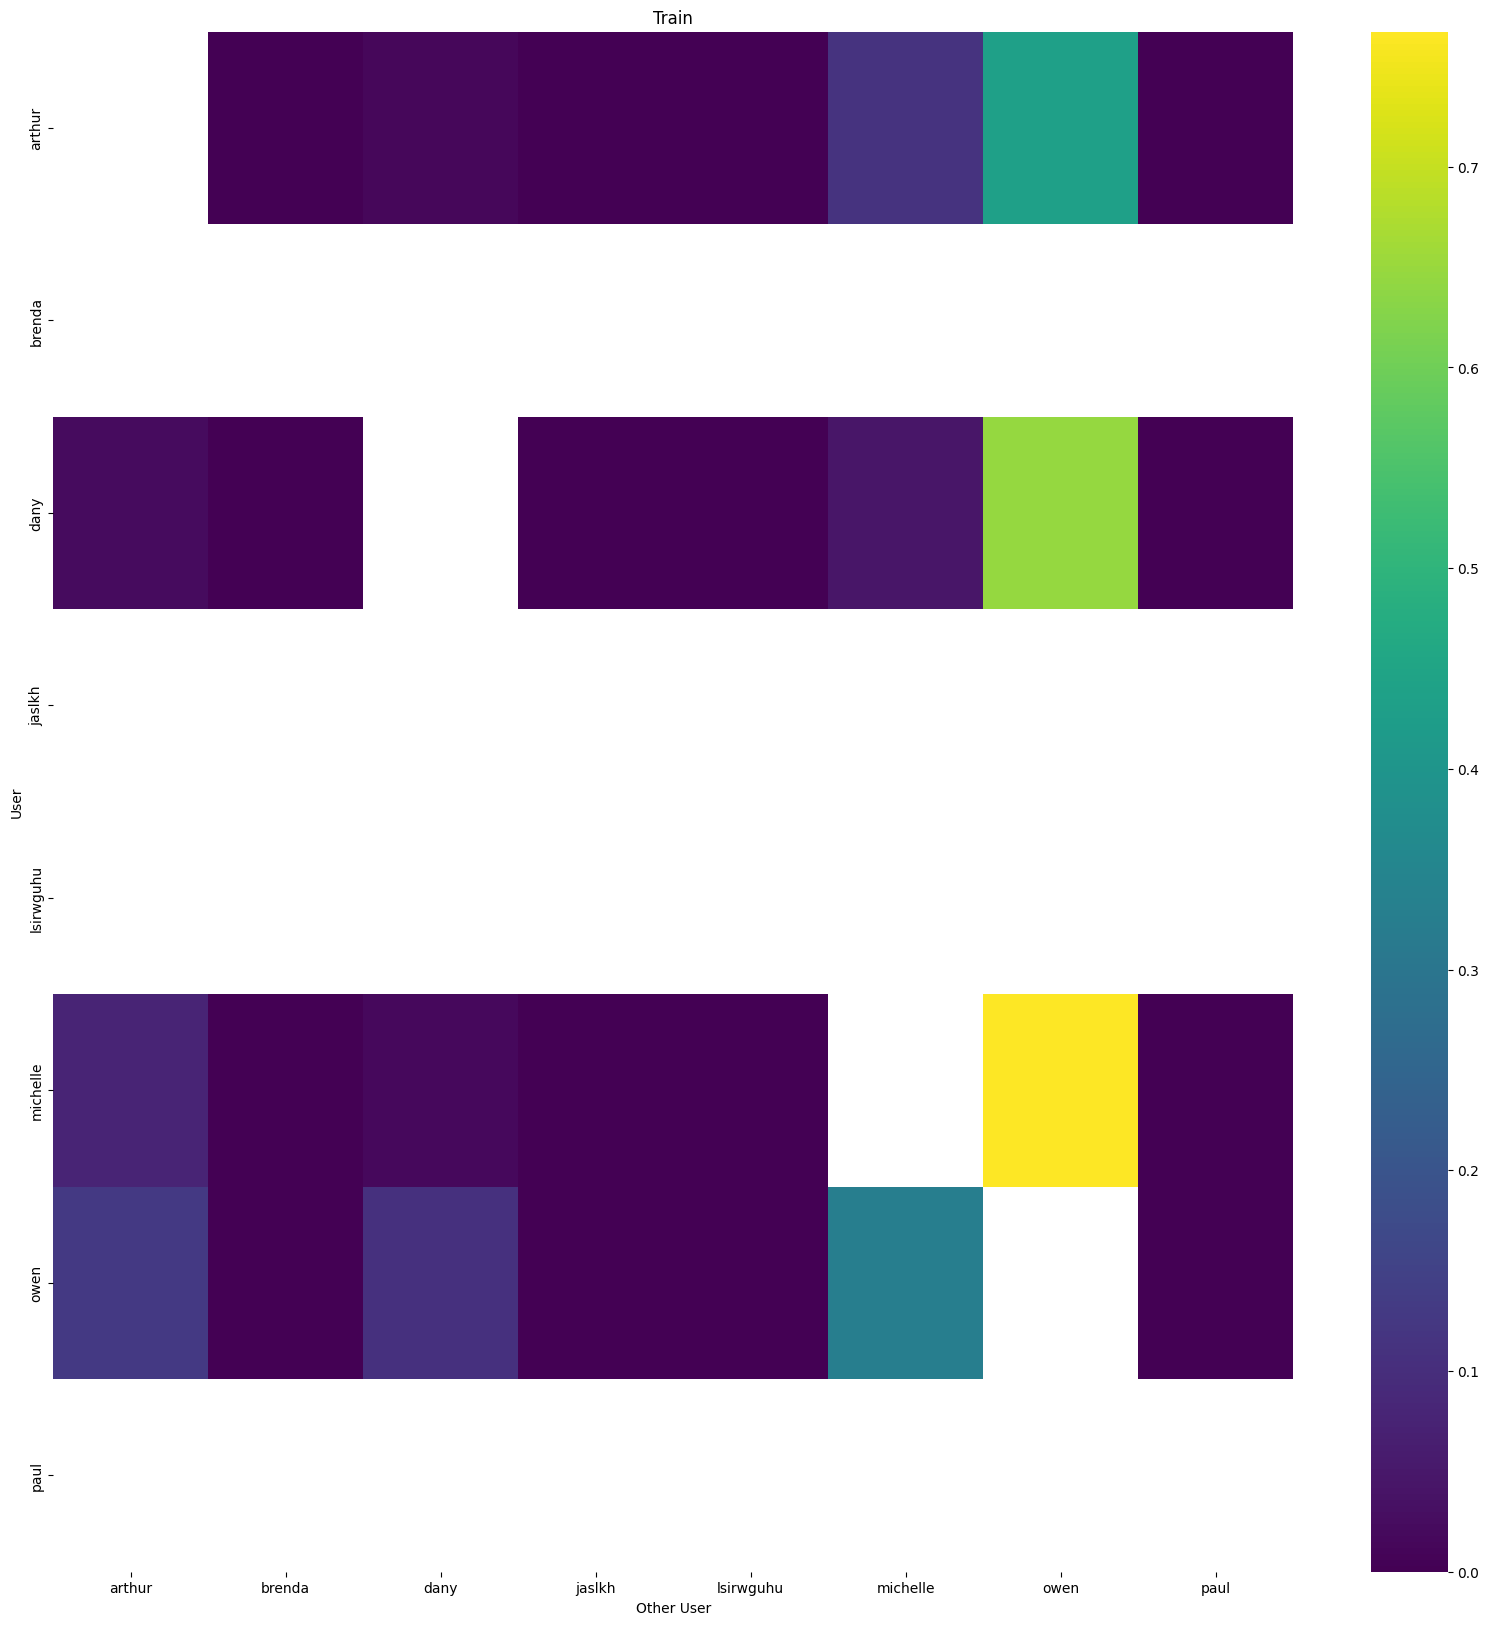

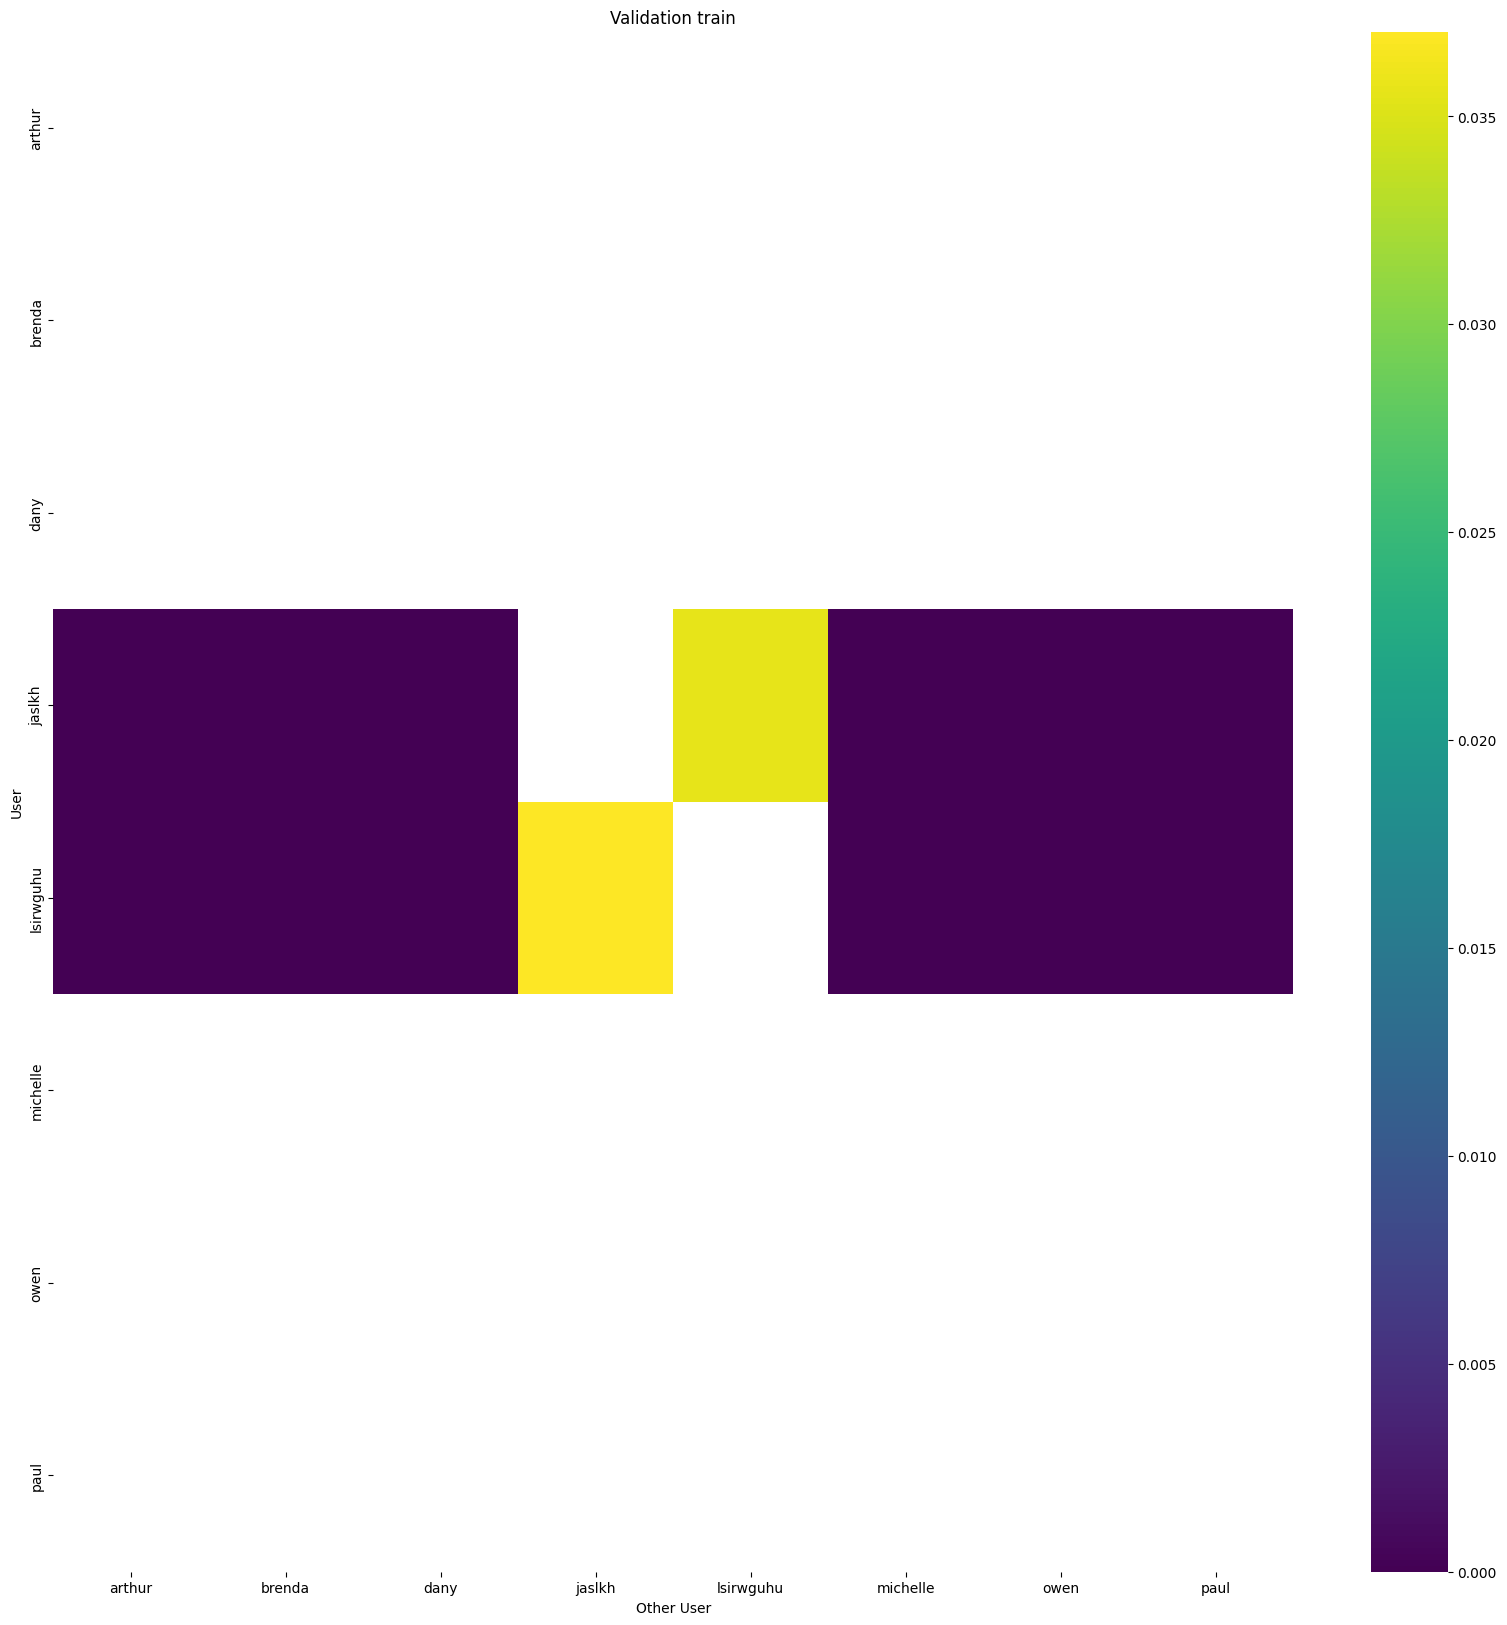

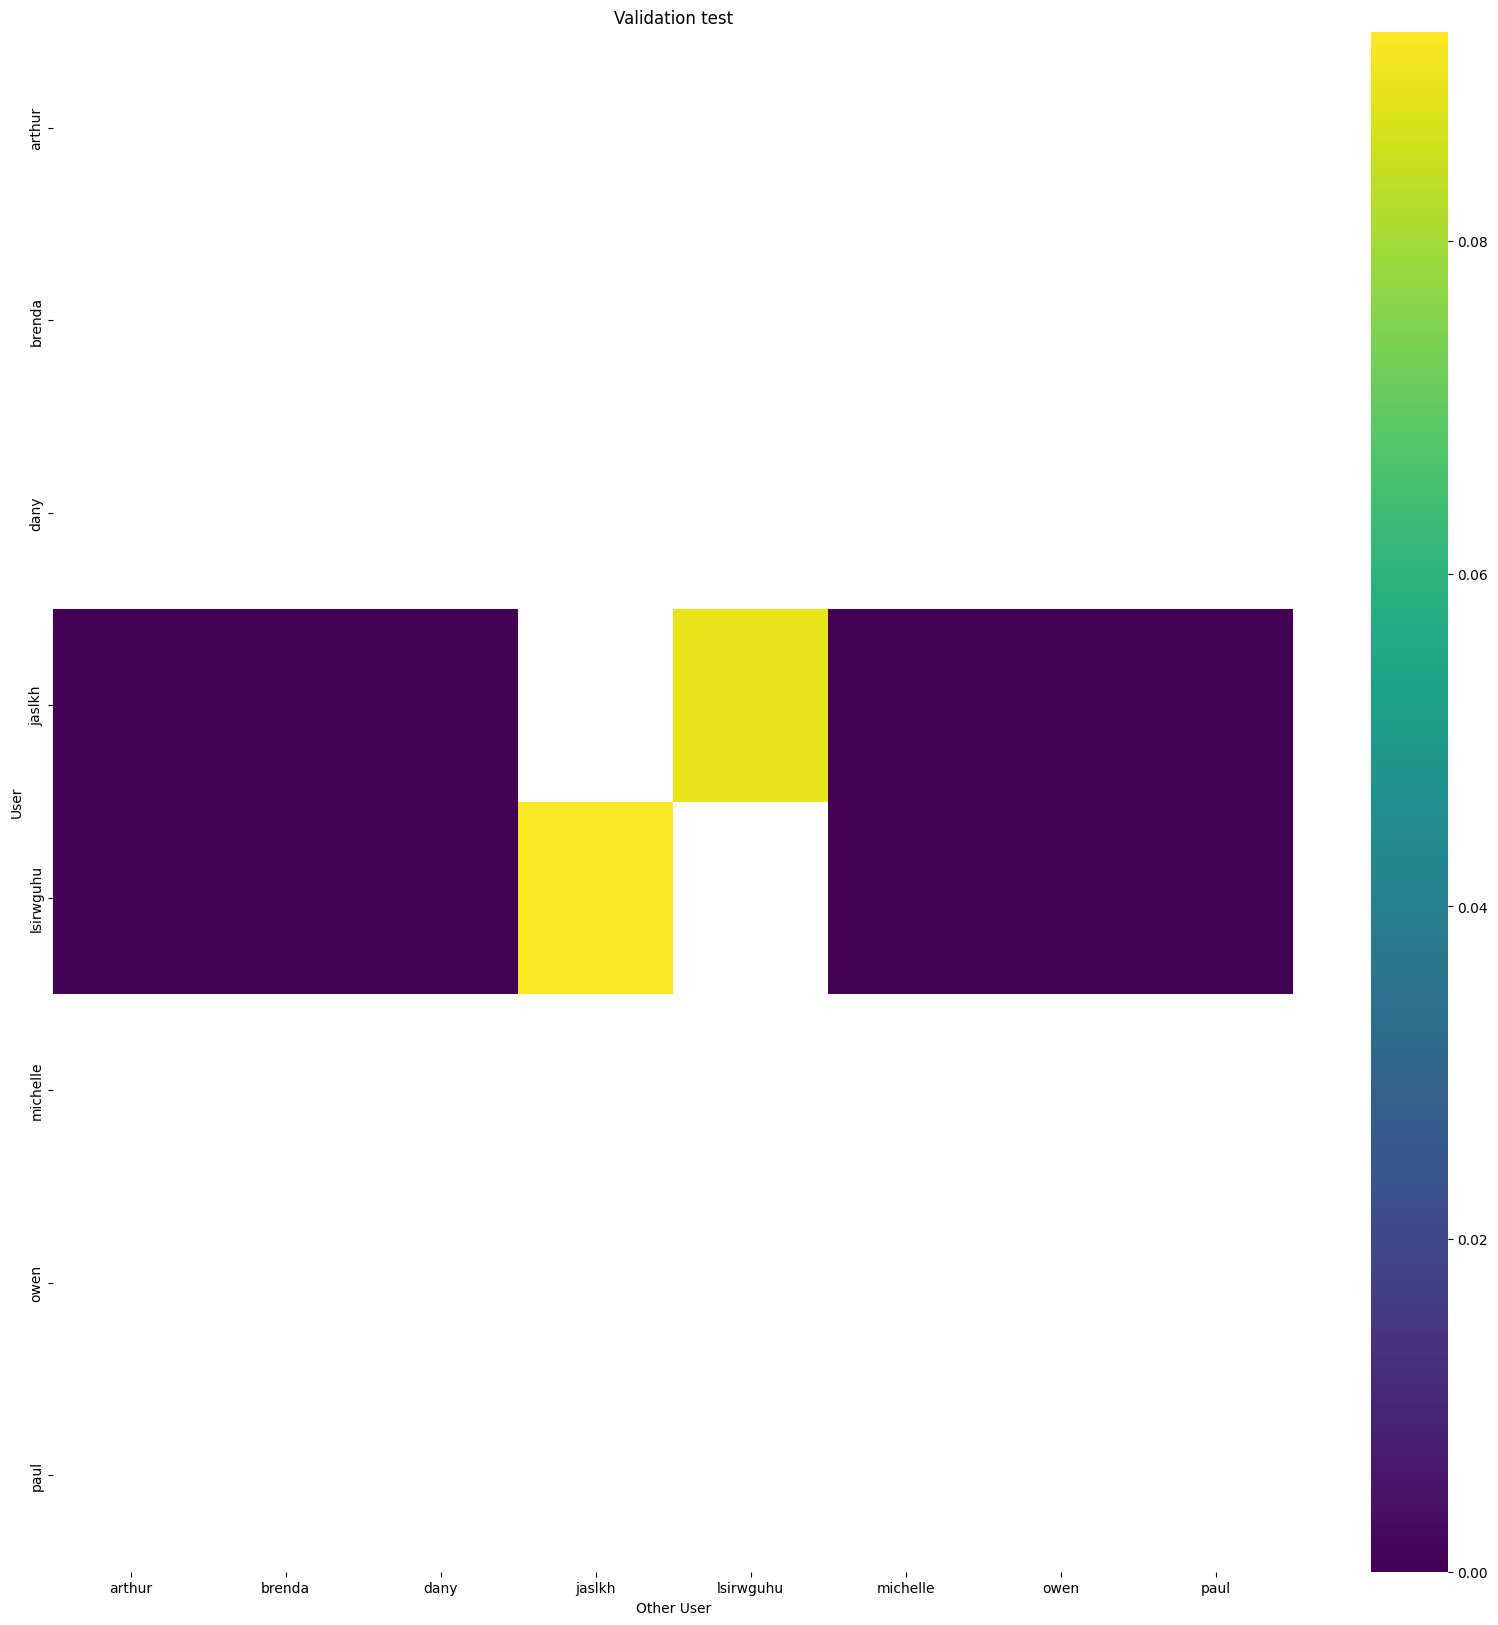

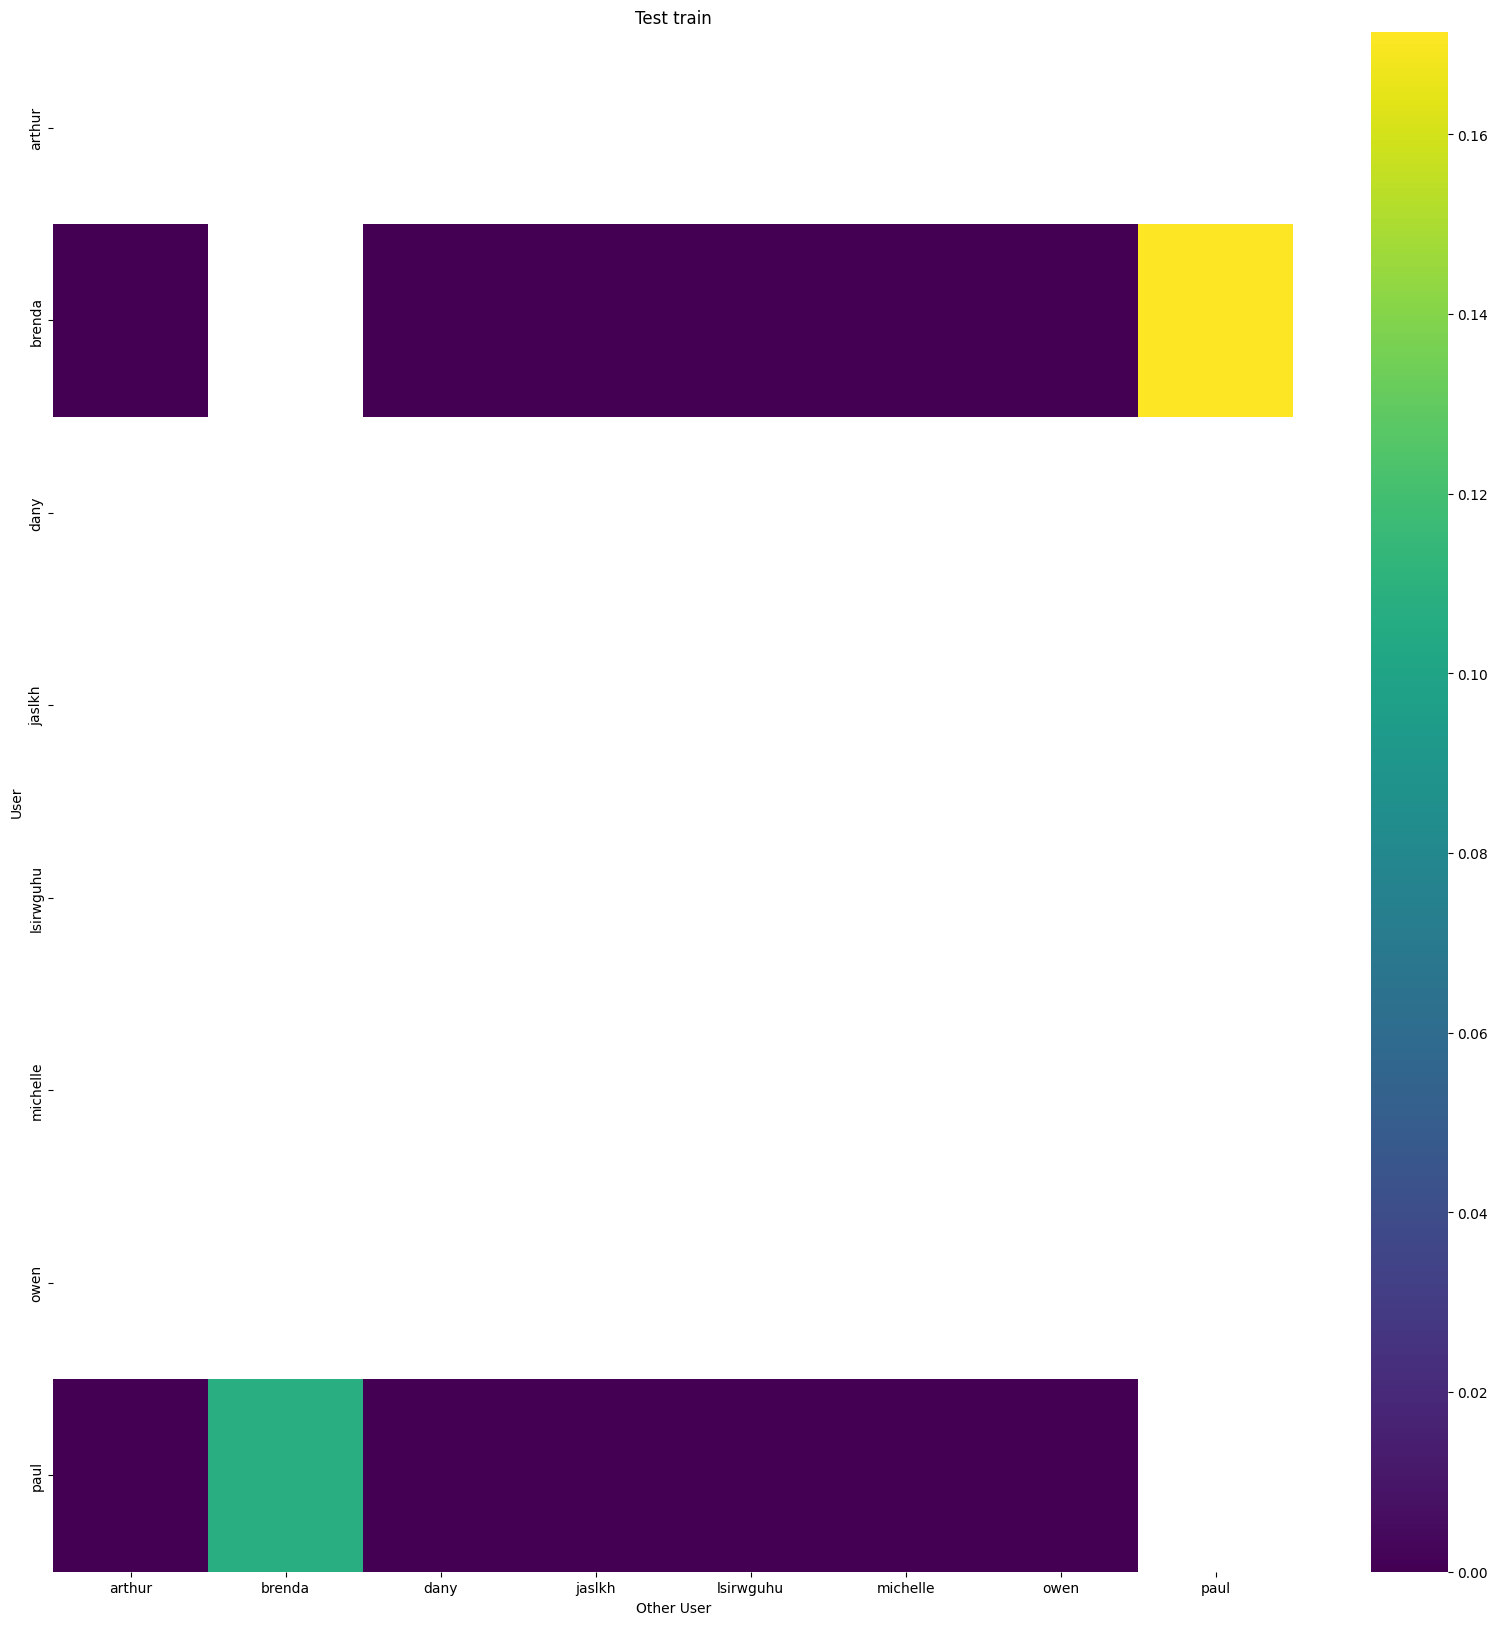

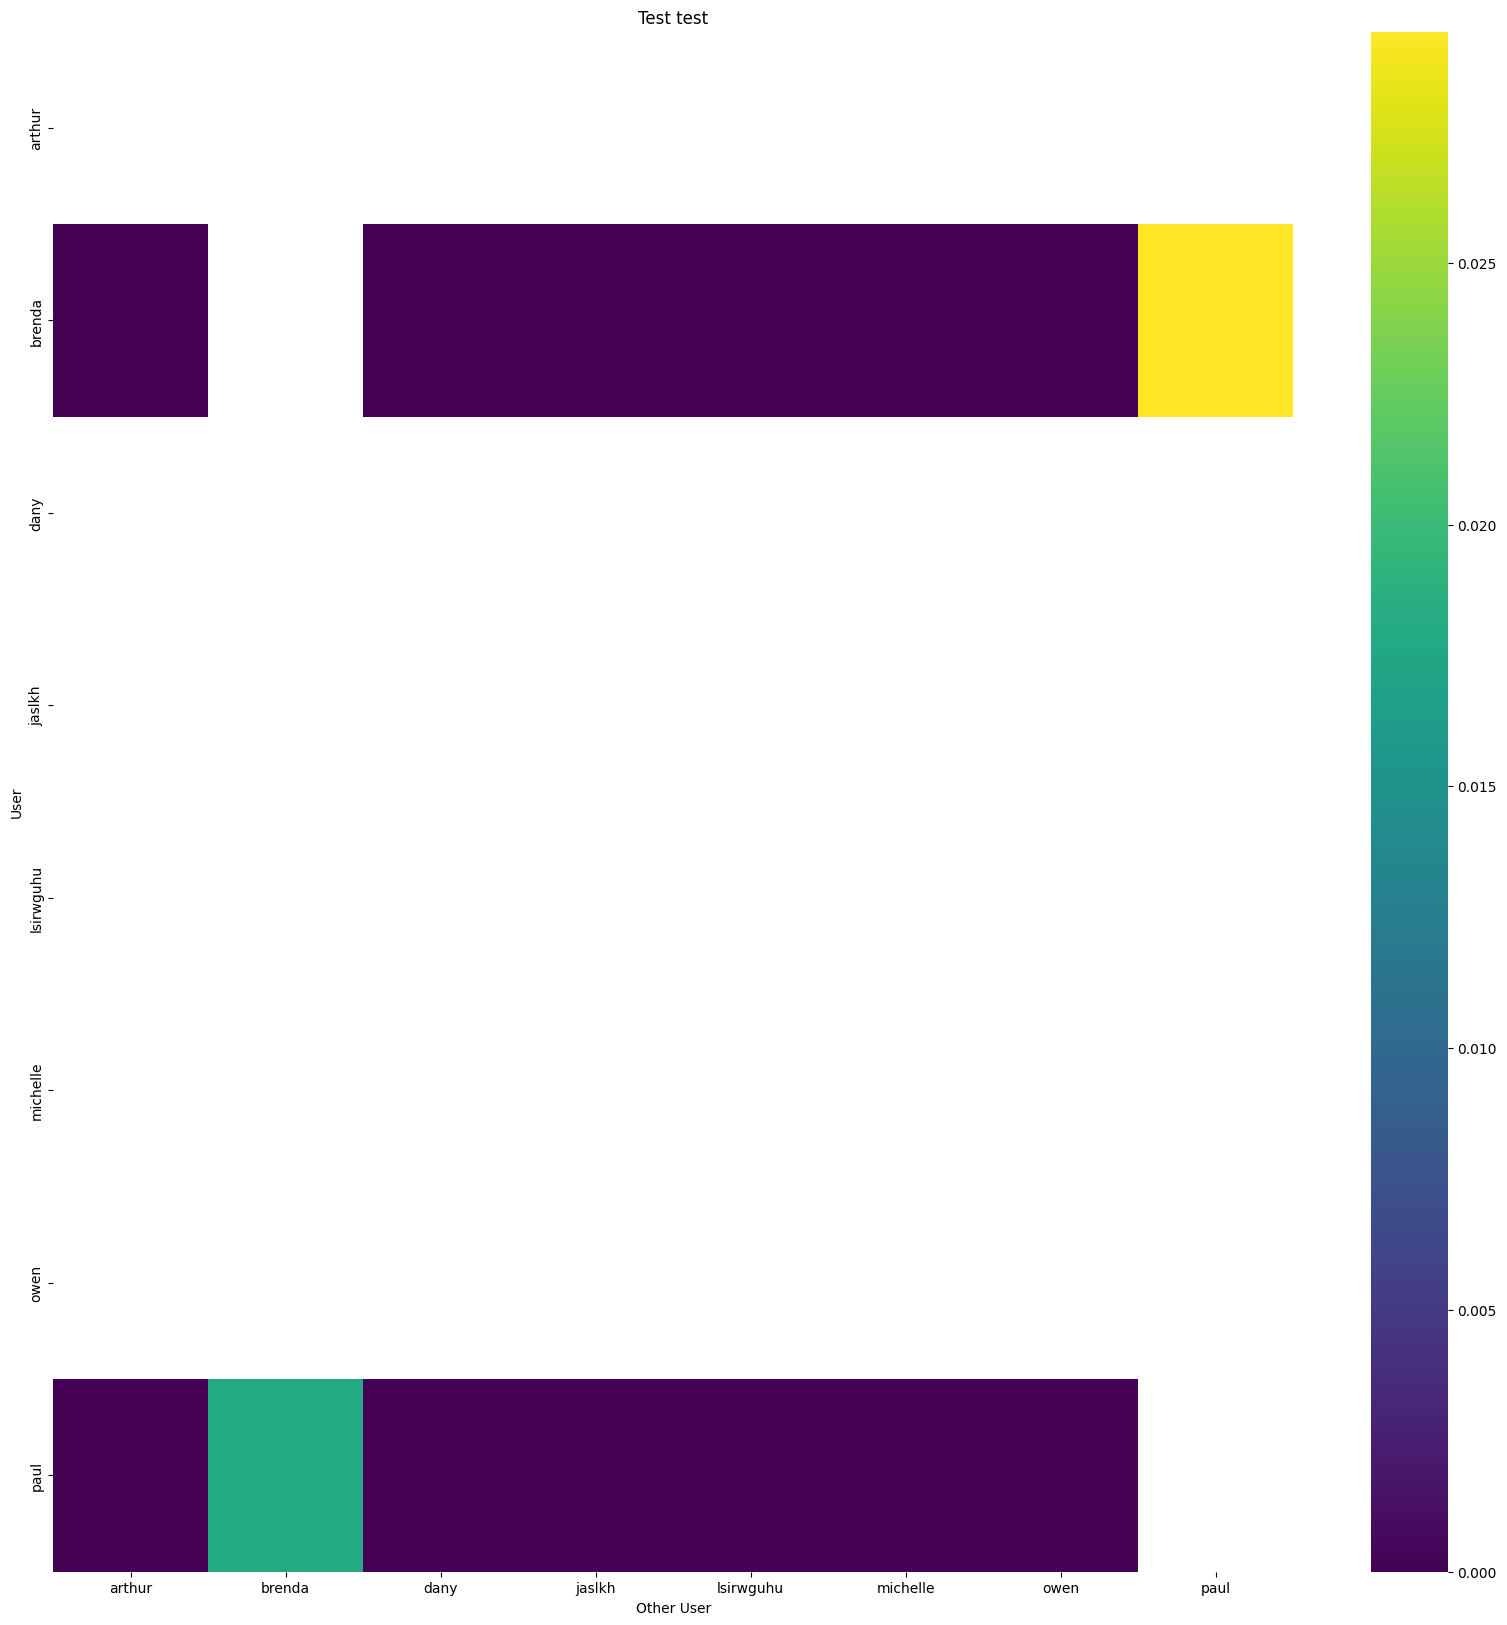

Alpha: 6.3247389793396
Min max affinity: 0.0 6.3247389793396
Min max affinity: 0.0 6.3247389793396
Min max affinity: 0.0 4.933296203613281
Min max affinity: 0.0 5.945254802703857
Min max affinity: 0.0 5.945254802703857
Min max affinity: 0.0 6.198244094848633
Max affinity: 6.3247389793396


In [12]:
train_df = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_df.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

df_user_similarities = user_similarities.calculate_users_track_common_percentage(train_df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation test")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test test")

(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=train_df,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

a = whole_matrix_dataset.compute_alpha()
whole_matrix_dataset.set_alpha(a)
# min_scale, max_scale = whole_matrix_dataset.min_max_scale(bounds=(0.0, 1.0))

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)
    # dataset.min_max_scale(bounds=(0.0, 1.0), optimums=(min_scale, max_scale))

print(f"Alpha: {a}")
print(f"Min max affinity: {whole_matrix_dataset.R.min().item()} {whole_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {train_matrix_dataset.R.min().item()} {train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_train_matrix_dataset.R.min().item()} {validation_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_test_matrix_dataset.R.min().item()} {validation_test_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_train_matrix_dataset.R.min().item()} {test_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_test_matrix_dataset.R.min().item()} {test_test_matrix_dataset.R.max().item()}")

max_affinity = whole_matrix_dataset.R.max().item()
print(f"Max affinity: {max_affinity}")

In [13]:
print("Whole dataset shape:", whole_matrix_dataset.R.shape)
print("Train dataset shape:", train_matrix_dataset.R.shape)
print("Validation train dataset shape:", validation_train_matrix_dataset.R.shape)
print("Validation test dataset shape:", validation_test_matrix_dataset.R.shape)
print("Test train dataset shape:", test_train_matrix_dataset.R.shape)
print("Test test dataset shape:", test_test_matrix_dataset.R.shape)

Whole dataset shape: torch.Size([8, 428])
Train dataset shape: torch.Size([8, 428])
Validation train dataset shape: torch.Size([8, 428])
Validation test dataset shape: torch.Size([8, 428])
Test train dataset shape: torch.Size([8, 428])
Test test dataset shape: torch.Size([8, 428])


In [14]:
whole_matrix_dataset.R

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.8974],
        ...,
        [3.1624, 3.1624, 0.0000,  ..., 0.0000, 3.1624, 0.0000],
        [3.1624, 0.0000, 2.7829,  ..., 0.0000, 3.1624, 1.8974],
        [0.0000, 0.0000, 3.1624,  ..., 5.8188, 0.0000, 0.0000]],
       device='mps:0')

# Define and train the MultiVAE model

In [15]:
num_latent_factors = 200
lmf = LogisticMatrixFactorization(
    num_users=whole_matrix_dataset.R.shape[0],
    num_items=whole_matrix_dataset.R.shape[1],
    num_factors=num_latent_factors,
    reg_param=0.01,
    device=device,
    dtype=dtype,
)
lmf.to(device)

num_epochs = 30
best_model = lmf.train_model(
    R=train_matrix_dataset.R,
    validation_test=validation_test_matrix_dataset.R,
    validation_train=validation_train_matrix_dataset.R,
    num_epochs=num_epochs,
    learning_rate=0.1,
    log_interval=1,
    tqdm=False
)

Epoch: 1 	 Loss: 13410.9834 	 MPR: 0.3867 	 NDCG@100: 0.1950 	 Recall@20: 0.2250 	 Recall@50: 0.1300
Epoch: 2 	 Loss: 7162.4292 	 MPR: 0.3115 	 NDCG@100: 0.2311 	 Recall@20: 0.2500 	 Recall@50: 0.1300
Epoch: 3 	 Loss: 4409.6470 	 MPR: 0.2729 	 NDCG@100: 0.2277 	 Recall@20: 0.2500 	 Recall@50: 0.1500
Epoch: 4 	 Loss: 3066.2339 	 MPR: 0.2422 	 NDCG@100: 0.1953 	 Recall@20: 0.2000 	 Recall@50: 0.1500
Epoch: 5 	 Loss: 2405.0066 	 MPR: 0.2308 	 NDCG@100: 0.2079 	 Recall@20: 0.1500 	 Recall@50: 0.1400
Epoch: 6 	 Loss: 2081.0417 	 MPR: 0.2177 	 NDCG@100: 0.2191 	 Recall@20: 0.2000 	 Recall@50: 0.1700
Epoch: 7 	 Loss: 1952.1246 	 MPR: 0.2166 	 NDCG@100: 0.2442 	 Recall@20: 0.1750 	 Recall@50: 0.1700
Epoch: 8 	 Loss: 1873.1810 	 MPR: 0.2105 	 NDCG@100: 0.2433 	 Recall@20: 0.2250 	 Recall@50: 0.2000
Epoch: 9 	 Loss: 1832.0679 	 MPR: 0.2132 	 NDCG@100: 0.2327 	 Recall@20: 0.1750 	 Recall@50: 0.1900
Epoch: 10 	 Loss: 1807.2222 	 MPR: 0.2088 	 NDCG@100: 0.2522 	 Recall@20: 0.2000 	 Recall@50: 0.180

In [16]:
losses_df = pd.DataFrame(
    [
        lmf.losses.cpu().numpy(),
        lmf.validation_losses.cpu().numpy(),
        lmf.ndcg_history.cpu().numpy(),
        lmf.recall20_history.cpu().numpy(),
        lmf.recall50_history.cpu().numpy(),
        lmf.mpr_history.cpu().numpy(),
    ]
).T
losses_df.columns = ["loss", "validation_loss", "ndcg", "r20", "r50", "mpr"]

px.line(
    losses_df, x=losses_df.index, y=["loss", "validation_loss"], title="Loss"
).show()
px.line(losses_df, x=losses_df.index, y=["ndcg", "r20", "r50", "mpr"], title="Metrics").show()

In [17]:
total_loss, ndcg, recall_20, recall_50, mpr = best_model.evaluate_model(
    R=whole_matrix_dataset.R,
    validation_test=validation_test_matrix_dataset.R,
    validation_train=validation_train_matrix_dataset.R
)
print(f"Total loss: {total_loss}")
print(f"NDCG_100: {ndcg}")
print(f"Recall_20: {recall_20}")
print(f"Recall_50: {recall_50}")
print(f"MPR: {mpr}")

Total loss: 3529.99267578125
NDCG_100: 0.25217124819755554
Recall_20: 0.20000000298023224
Recall_50: 0.18000000715255737
MPR: 0.3216361701488495


In [18]:
df_tracks = df_matrix_mf_filtered.copy()
df_tracks = df_tracks.sample(frac=1) # Shuffle the dataframe
df_tracks = df_tracks[:150] # Keep only 1000 tracks
df_tracks["username"] = df_tracks["username"].cat.remove_unused_categories()
df_tracks["id"] = df_tracks["id"].cat.remove_unused_categories()

# Add item latent factors to the dataframe
n_components = 3
items_latent_columns = [f"track_latent_{i}" for i in range(n_components)]
pca_items = PCA(n_components=n_components)
pca_items.fit(lmf.item_vectors.cpu().numpy())
for track_id in df_tracks["id"].unique():
    latent_factors = lmf.get_item_factors([whole_matrix_dataset.itemnames_to_ids([track_id])[0]]).tolist()
    df_tracks.loc[df_tracks["id"] == track_id, items_latent_columns] = pca_items.transform(latent_factors).flatten()

# Add user latent factors to the dataframe
users_latent_columns = [f"user_latent_{i}" for i in range(n_components)]
pca_user = PCA(n_components=n_components)
pca_user.fit(lmf.user_vectors.cpu().numpy())
for user_id in df_tracks["username"].unique():
    latent_factors = lmf.get_user_factors([whole_matrix_dataset.usernames_to_ids([user_id])[0]]).tolist()
    df_tracks.loc[df_tracks["username"] == user_id, users_latent_columns] = pca_user.transform(latent_factors).flatten()

plotting.plot_latent_space(
    df=df_tracks,
    color=df_tracks["username"],
    text=df_tracks["username"],
    latent_columns=items_latent_columns,
).show()

plotting.plot_latent_space(
    df=df_tracks,
    color=df_tracks["username"],
    text=df_tracks["username"],
    latent_columns=users_latent_columns,
).show()

/Users/owen/local/unibe/ml/spotify-recommender/.venv/lib/python3.10/site-packages/plotly/express/_core.py:2044: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



/Users/owen/local/unibe/ml/spotify-recommender/.venv/lib/python3.10/site-packages/plotly/express/_core.py:2044: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [21]:
user_id = whole_matrix_dataset.usernames_to_ids(["paul"])[0]
print(user_id)

# Get the top 10 recommendations for the user
top_10_ids, top_10_ids_scores = lmf.recommend(R=whole_matrix_dataset.R, user_id=user_id, top_k=20, filter_user_items=False)

# Get the top 10 recommendations for the user
whole_matrix_dataset.item_ids_to_df(top_10_ids)[spoti.PRETTY_PRINT_FEATURES]

7


,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
103,jaslkh,Sebastian Yatra,Dos Oruguitas,2021,69,0.423,0.355,0.0454,0.761000,0.000000,0.0915,0.465,93.788,-10.565,214613,2021,69
107,jaslkh,Orelsan,Ensemble,2021,53,0.701,0.621,0.0425,0.012100,0.000000,0.0934,0.290,116.028,-9.428,283148,2021,53
154,jaslkh,Emma Peters,Gisèle,2021,63,0.762,0.481,0.2340,0.519000,0.015400,0.1240,0.317,108.989,-11.057,196162,2021,63
490,jaslkh,The Rolling Stones,"Paint It, Black",1966,85,0.464,0.795,0.0926,0.049300,0.002440,0.3990,0.612,158.691,-9.267,202266,1966,85
515,jaslkh,Ornella Vanoni,L'appuntamento,1996,64,0.406,0.371,0.0296,0.820000,0.000007,0.2640,0.718,112.117,-10.507,274000,1996,64
708,jaslkh,BONES,AirplaneMode,2019,76,0.847,0.601,0.1030,0.163000,0.787000,0.1100,0.548,139.996,-6.311,75428,2019,76
1578,owen,Turnover,Cutting My Fingers Off,2015,58,0.419,0.665,0.0367,0.042100,0.067500,0.1250,0.245,157.064,-7.868,195984,2015,58
1763,owen,Doja Cat,You Right,2021,83,0.828,0.621,0.0565,0.016400,0.002330,0.0845,0.436,128.986,-6.414,186173,2021,83
1898,owen,宇宙ネコ子,Virgin Suicide,2019,50,0.382,0.632,0.0394,0.000016,0.945000,0.0644,0.102,117.972,-6.416,186965,2019,50
1928,owen,OBOY,TDB,2021,61,0.882,0.675,0.1410,0.047400,0.000598,0.1240,0.758,140.092,-6.004,154280,2021,61
